Chapter 01

# 掷色子实验
《概率统计》 | 鸢尾花书：数学不难

这段代码的主要目的是模拟**掷一颗公平的六面色子500次**的实验，并从数学角度分析每个点数在过程中出现的频率，进而研究**频率如何逐渐趋近于理论概率**的现象。代码最终通过两幅图像将掷出的结果与累积概率直观展示出来。

---

首先，设定随机种子 `np.random.seed(88)` 保证模拟结果可重复。接着，使用 `np.random.randint(1, 7, size=n_throws)` 生成一个长度为 \$n = 500\$ 的整数序列 \$x\_1, x\_2, \dots, x\_{500}\$，其中每个 \$x\_i \in {1, 2, 3, 4, 5, 6}\$ 对应一次掷色子的结果。由于使用的是均匀随机采样，因此在理论上，每个点数 \$k\$ 出现的概率为

$$
P(X = k) = \frac{1}{6}, \quad k = 1, 2, \dots, 6
$$

接下来，为了研究**频率收敛于概率**的现象，代码构造了一个形状为 \$(500, 6)\$ 的二维数组 `cumulative_probs`。其中第 \$i\$ 行的第 \$j\$ 列表示前 \$i+1\$ 次实验中，点数为 \$j+1\$ 的频率，即：

$$
\hat{P}_i(X = j+1) = \frac{1}{i+1} \sum_{t=1}^{i+1} \mathbb{1}(x_t = j+1)
$$

这里，\$\mathbb{1}(\cdot)\$ 是指示函数，当括号内条件为真时取值1，否则取0。这个表达式是经验概率（或称为频率）的定义，描述的是某一事件在实验中出现的相对次数。

举个例子，如果前10次掷色子中，“点数3”出现了2次，那么 \$\hat{P}\_9(X=3) = 2/10 = 0.2\$。随着 \$i\$ 增加（即实验次数增加），我们期望 \$\hat{P}\_i(X = k) \to P(X = k) = 1/6\$，这正是**大数定律**的一个体现。

---

可视化部分分为两个子图：

* 上图 `ax1`：展示了每一次掷色子的结果 \$x\_i\$。横轴是掷色子的编号 \$i\$，纵轴是结果 \$x\_i\$。彩色散点图便于观察每个点数在整个过程中如何分布。

* 下图 `ax2`：展示了每个点数 \$k = 1, 2, ..., 6\$ 的累积频率 \$\hat{P}\_i(X = k)\$ 随着掷色子次数 \$i\$ 的变化曲线。这六条曲线应该都在逐渐趋近于 \$\frac{1}{6} \approx 0.167\$。这也就是在验证：

$$
\lim_{n \to \infty} \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}(x_i = k) = \frac{1}{6}
$$

对于每一个点数 \$k\$，这就是经典概率论中**频率趋于概率**的数学表达。

---

整体而言，这段代码构建了一个完整的概率实验模型，从生成样本到频率估计，再到大数定律的验证，用图形将抽象的数学概念变得直观、生动。


## 初始化

In [5]:
import matplotlib.pyplot as plt
import numpy as np

## 模拟掷色子

In [7]:
# 设置随机种子
np.random.seed(88)

# 模拟抛掷500次
n_throws = 500
throws = np.random.randint(1, 7, size=n_throws)

# 抛掷编号
x_vals = np.arange(1, n_throws + 1)

In [8]:
# 点数颜色映射
colors_map = {
    1: '#FF0000',  # 红
    2: '#00AA00',  # 绿
    3: '#0000FF',  # 蓝
    4: '#FF9900',  # 橙
    5: '#9900FF',  # 紫
    6: '#00CCCC',  # 青
}
colors = [colors_map[val] for val in throws]

## 计算累积概率

In [10]:
cumulative_probs = np.zeros((n_throws, 6))

for i in range(n_throws):
    counts = np.bincount(throws[:i+1], minlength=7)[1:]  # 忽略0
    cumulative_probs[i] = counts / (i + 1)

## 可视化

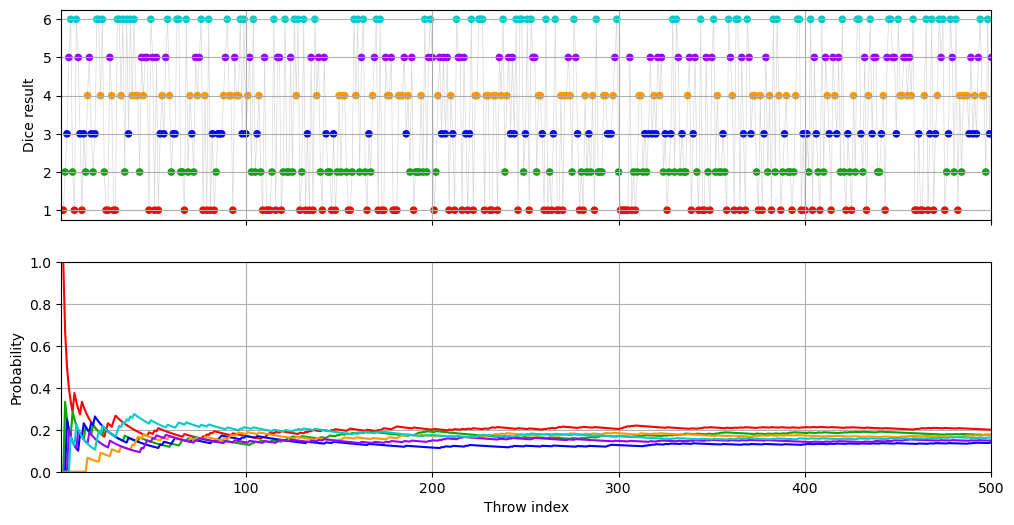

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), 
                               height_ratios=[1, 1], 
                               sharex=True)

# 上图
ax1.plot(x_vals, throws, color='gray', linewidth=0.5, alpha=0.3)
ax1.scatter(x_vals, throws, c=colors, s=20)
ax1.set_ylabel('Dice result')
ax1.set_yticks([1, 2, 3, 4, 5, 6])
ax1.set_xlim(1, x_vals.max())
ax1.grid(True)

# 下图
for i in range(6):
    ax2.plot(x_vals, cumulative_probs[:, i], color=colors_map[i+1])
ax2.set_xlabel('Throw index')
ax2.set_ylabel('Probability')
ax2.set_xlim(1, x_vals.max())
ax2.set_ylim(0, 1)
ax2.grid(True)

作者	**生姜DrGinger**  
脚本	**生姜DrGinger**  
视频	**崔崔CuiCui**  
开源资源	[**GitHub**](https://github.com/Visualize-ML)  
平台	[**油管**](https://www.youtube.com/@DrGinger_Jiang)		
		[**iris小课堂**](https://space.bilibili.com/3546865719052873)		
		[**生姜DrGinger**](https://space.bilibili.com/513194466)  